In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('emg_data.csv')
label_map = {0: 'Normal', 1: 'Moderate', 2: 'High'}
df['status'] = df['label'].map(label_map)

In [3]:
print("=== Basic Info ===")
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())

=== Basic Info ===
(3000, 3)
rms       float64
label       int64
status     object
dtype: object
rms       0
label     0
status    0
dtype: int64


In [4]:
print("\n=== Statistics per Class ===")
print(df.groupby('status')['rms'].describe())


=== Statistics per Class ===
           count         mean         std          min          25%  \
status                                                                
High      1000.0  2807.304408  153.076647  2337.652308  2705.099045   
Moderate  1000.0  2209.656392  107.999450  1828.061613  2137.995696   
Normal    1000.0  1960.179412   69.353304  1800.000000  1914.950345   

                  50%          75%          max  
status                                           
High      2807.881338  2915.750576  3200.000000  
Moderate  2214.524571  2282.748039  2603.027058  
Normal    1956.840982  2004.182365  2253.657470  


C:\Users\sAadh\AppData\Local\Temp\ipykernel_17576\319459245.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0,2].boxplot(


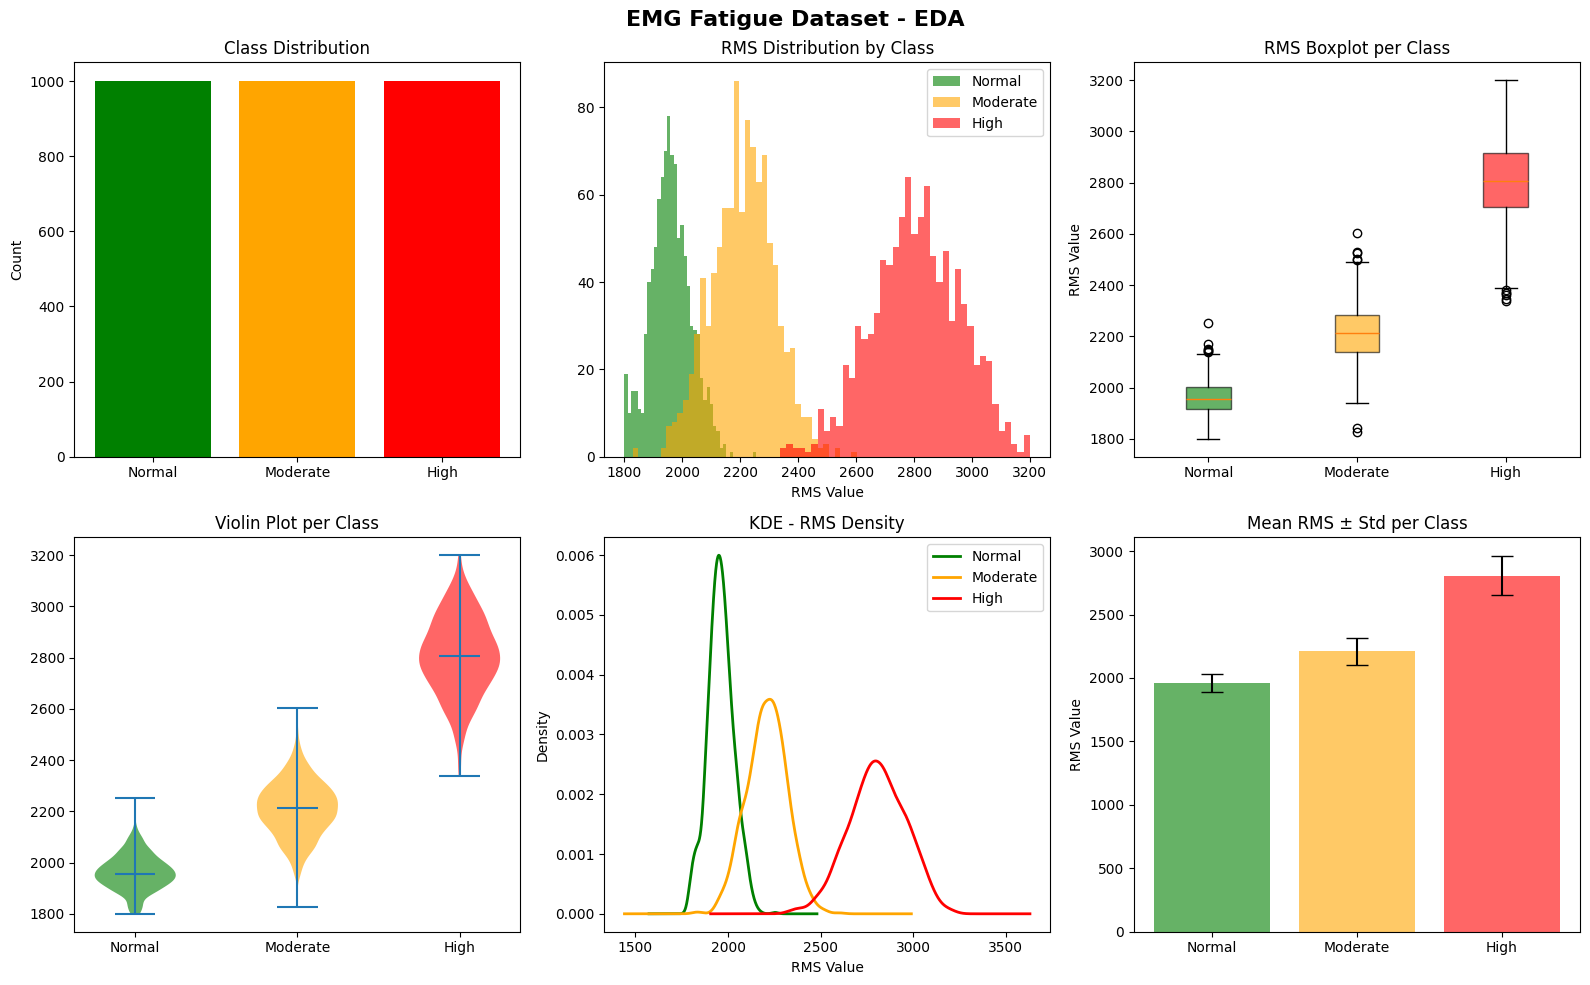

Saved to eda_report.png


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EMG Fatigue Dataset - EDA', fontsize=16, fontweight='bold')

# 1. Class distribution
axes[0,0].bar(label_map.values(), df['label'].value_counts().sort_index(), color=['green','orange','red'])
axes[0,0].set_title('Class Distribution')
axes[0,0].set_ylabel('Count')

# 2. RMS distribution by class
for label, color in zip([0,1,2], ['green','orange','red']):
    subset = df[df['label'] == label]['rms']
    axes[0,1].hist(subset, bins=40, alpha=0.6, color=color, label=label_map[label])
axes[0,1].set_title('RMS Distribution by Class')
axes[0,1].set_xlabel('RMS Value')
axes[0,1].legend()

# 3. Boxplot
colors = ['green','orange','red']
bp = axes[0,2].boxplot(
    [df[df['label']==i]['rms'].values for i in [0,1,2]],
    labels=label_map.values(), patch_artist=True
)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0,2].set_title('RMS Boxplot per Class')
axes[0,2].set_ylabel('RMS Value')

# 4. Violin plot
parts = axes[1,0].violinplot(
    [df[df['label']==i]['rms'].values for i in [0,1,2]],
    positions=[1,2,3], showmedians=True
)
for pc, color in zip(parts['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.6)
axes[1,0].set_xticks([1,2,3])
axes[1,0].set_xticklabels(label_map.values())
axes[1,0].set_title('Violin Plot per Class')

# 5. KDE plot
for label, color in zip([0,1,2], colors):
    subset = df[df['label']==label]['rms']
    subset.plot.kde(ax=axes[1,1], color=color, label=label_map[label], linewidth=2)
axes[1,1].set_title('KDE - RMS Density')
axes[1,1].set_xlabel('RMS Value')
axes[1,1].legend()

# 6. Mean and std per class
means = df.groupby('label')['rms'].mean()
stds  = df.groupby('label')['rms'].std()
axes[1,2].bar(label_map.values(), means, yerr=stds, color=colors, alpha=0.6, capsize=8)
axes[1,2].set_title('Mean RMS ± Std per Class')
axes[1,2].set_ylabel('RMS Value')

plt.tight_layout()
plt.savefig('eda_report.png', dpi=150)
plt.show()
print("Saved to eda_report.png")

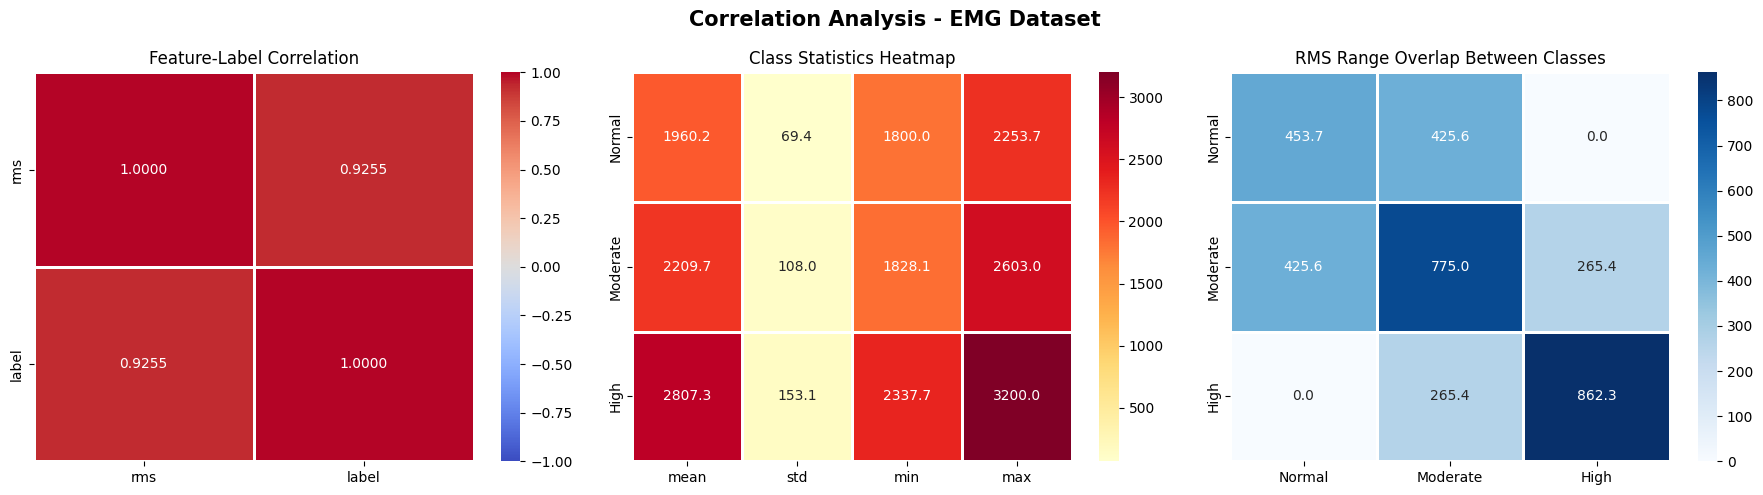


rms vs label correlation: 0.9255


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Correlation Analysis - EMG Dataset', fontsize=15, fontweight='bold')

# 1. rms vs label correlation heatmap
corr = df[['rms', 'label']].corr()
sns.heatmap(corr, annot=True, fmt='.4f', cmap='coolwarm',
            linewidths=1, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Feature-Label Correlation')

# 2. Class mean heatmap (rms statistics per class)
stats = df.groupby('label')['rms'].agg(['mean','std','min','max'])
stats.index = label_map.values()
sns.heatmap(stats, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=1, ax=axes[1])
axes[1].set_title('Class Statistics Heatmap')

# 3. RMS range overlap heatmap between classes
classes = [0, 1, 2]
overlap_matrix = np.zeros((3, 3))
for i in classes:
    for j in classes:
        a = df[df['label']==i]['rms']
        b = df[df['label']==j]['rms']
        overlap = (min(a.max(), b.max()) - max(a.min(), b.min()))
        overlap_matrix[i][j] = max(0, overlap)

sns.heatmap(overlap_matrix, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=label_map.values(),
            yticklabels=label_map.values(),
            linewidths=1, ax=axes[2])
axes[2].set_title('RMS Range Overlap Between Classes')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
print(f"\nrms vs label correlation: {df['rms'].corr(df['label']):.4f}")